# Dátová analýza pacientov so synkopou

Tento notebook obsahuje praktickú časť bakalárskej práce zameranú na predspracovanie klinických údajov, vytvorenie cieľovej premennej recidíva, imputáciu chýbajúcich hodnôt, trénovanie klasifikačných modelov a identifikáciu rizikových faktorov opakovania synkopy.

Notebook je členený podľa hlavných krokov analytického procesu: načítanie a čistenie dát, transformácia premenných, imputácia chýbajúcich hodnôt, trénovanie modelov, vyhodnotenie výsledkov a analýza dôležitosti premenných.

In [2]:
# načítanie knižníc potrebných na spracovanie dát, modelovanie, vizualizáciu a vyhodnotenie modelov
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)


In [3]:
# načítanie datasetu, vytvorenie cieľovej premennej recidiva a základné čistenie údajov
data = pd. read_csv("data_full.csv")

# vytvorenie cieľovej premennej "recidiva" na základe počtu epizód synkopy v stĺpci C2
data["recidiva"] = np.where(
    data["C2"] == -1,
    -1,
    (data["C2"] > 1).astype(int)
)

# odstránenie záznamov, pri ktorých nebolo možné určiť cieľovú premennú
data.drop(data[data['recidiva'] == -1].index, inplace=True)
data.reset_index(drop=True, inplace=True) # obnovenie indexov po odstránení riadkov

# odstránenie stĺpcov, ktoré sa nepoužívajú ako vstupné premenné pre modelovanie
cols_to_drop = [col for col in data.columns if col.startswith('A') and col not in ['A2', 'A4']] 
data.drop(columns=cols_to_drop, inplace=True)
data.drop(columns= ['Typ Synkopy','Synkopa','C2'], inplace=True) 

# prevod premennej Pohlavie do číselnej formy
data["Pohlavie"] = (
    data["Pohlavie"]
    .str.strip()      # odstránenie prípadných medzier v hodnotách
    .map({"F": 0, "M": 1})
)

data["O1"] = data["O1"].apply(lambda x: 1 if x not in [0,1] else x)

# Funkcia rozdelí krvný tlak vo formáte "systolický/diastolický" na dve číselné premenné
def split_bp(series):
    s = series.replace(-1, np.nan).astype(str)
    mask = s.str.match(r'^\d+/\d+$')  # akceptuje sa iba formát napr. 120/80

    parts = s.where(mask).str.split("/", expand=True)

    sbp = pd.to_numeric(parts[0], errors="coerce")
    dbp = pd.to_numeric(parts[1], errors="coerce")

    return sbp, dbp, mask

# vytvorenie nových premenných pre systolický a diastolický tlak
data["SBP_before"], data["DBP_before"], mask_before = split_bp(data["A2"])
data["SBP_tilt"], data["DBP_tilt"], mask_tilt = split_bp(data["A4"])

# ak je formát tlaku neplatný, hodnoty sa ponechajú ako NaN
valid = mask_before & mask_tilt
data.loc[~valid, ["SBP_before","DBP_before","SBP_tilt","DBP_tilt"]] = np.nan

#  odstránenie pôvodných stĺpcov A2 a A4
data = data.drop(columns=["A2", "A4"])

# nahradenie hodnoty -1 hodnotou NaN, keďže -1 v datasete označuje chýbajúce údaje
data = data.replace(-1, np.nan)
data.head(10)
data.shape


(289, 116)

In [4]:
# výber premenných, ktoré budú použité v ďalšej analýze a modelovaní
selected_columns = [
    "Pohlavie","Vek",
    "O1","P1","P2","P3","P4","P5","P6",
    "P10","P11","P14","P15","P24","P26",
    "SBP_before","DBP_before",
    "SBP_tilt","DBP_tilt",
    "recidiva"
]
selected_columns = [c for c in selected_columns if c in data.columns]

data = data[selected_columns]

data.reset_index(drop=True, inplace=True)
data.head(15)

,Pohlavie,Vek,O1,P1,P2,P3,P4,P5,P6,P10,P11,P14,P15,P24,P26,SBP_before,DBP_before,SBP_tilt,DBP_tilt,recidiva
0,0,23.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110.0,60.0,120.0,80.0,1
1,1,23.0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,120.0,80.0,100.0,60.0,1
2,1,27.0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,140.0,80.0,120.0,80.0,0
3,1,74.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,0,69.0,0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,130.0,80.0,130.0,80.0,1
5,0,62.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,130.0,80.0,130.0,80.0,1
6,1,60.0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,110.0,70.0,110.0,80.0,0
7,0,51.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,120.0,80.0,100.0,60.0,1
8,0,26.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,110.0,80.0,100.0,60.0,0
9,0,56.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110.0,60.0,100.0,60.0,1


## Model XGBoost

Táto časť trénuje model XGBoost, ktorý dokáže pracovať aj s chýbajúcimi hodnotami. Model sa následne vyhodnocuje pomocou metrík Accuracy, AUC, Precision, Recall, F1-score, matice zámen a ROC krivky.

In [6]:
# trénovanie modelu XGBoost a výpočet základných klasifikačných metrík
df = data.copy()

X = df.drop(columns=["recidiva"])
y = df["recidiva"].astype(int)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train_xgb, y_train_xgb)

y_pred_xgb = xgb.predict(X_test_xgb)
y_proba_xgb = xgb.predict_proba(X_test_xgb)[:, 1]

acc_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
auc_xgb = roc_auc_score(y_test_xgb, y_proba_xgb)

print("ROC AUC:", auc_xgb)
print("ACC:", acc_xgb)
print("Confusion matrix:\n", confusion_matrix(y_test_xgb, y_pred_xgb))
print(classification_report(y_test_xgb, y_pred_xgb))


ROC AUC: 0.8622668579626973
ACC: 0.8275862068965517
Confusion matrix:
 [[13  4]
 [ 6 35]]
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.90      0.85      0.88        41

    accuracy                           0.83        58
   macro avg       0.79      0.81      0.80        58
weighted avg       0.83      0.83      0.83        58



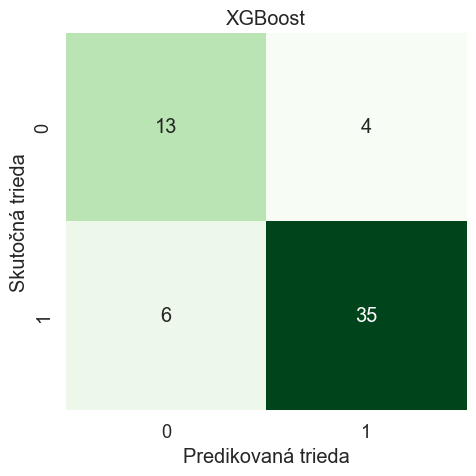

In [7]:
# zobrazenie matice zámen pre model XGBoost

# výpočet matice zámen
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)

# vizualizácia matice zámen
plt.figure(figsize=(5,5))
sns.set(font_scale=1.2)

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)

plt.title("XGBoost")
plt.xlabel("Predikovaná trieda")
plt.ylabel("Skutočná trieda")

plt.tight_layout()
plt.show()

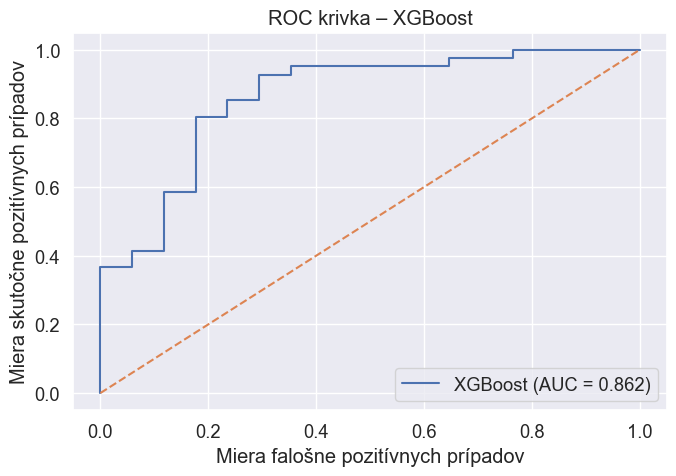

In [8]:
# ROC krivka – XGBoost

y_proba_xgb = xgb.predict_proba(X_test_xgb)[:, 1]

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test_xgb, y_proba_xgb)
roc_auc_xgb = roc_auc_score(y_test_xgb, y_proba_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Miera falošne pozitívnych prípadov")
plt.ylabel("Miera skutočne pozitívnych prípadov")
plt.title("ROC krivka – XGBoost")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## Príprava dát pre modely vyžadujúce úplný dataset

Nasledujúce modely nepracujú priamo s chýbajúcimi hodnotami, preto sú pripravené dve verzie dát: jednoduchá imputácia a pokročilá imputácia MICE.

### Jednoduchá imputácia chýbajúcich hodnôt

Chýbajúce hodnoty sú doplnené najčastejšie sa vyskytujúcou hodnotou v danom atribúte. Tento postup je vhodný najmä preto, že väčšina premenných má binárny charakter.

In [11]:
# rozdelenie dát a aplikácia jednoduchej imputácie na chýbajúce hodnoty
df = data.copy()

# rozdelenie dát na vstupné premenné X a cieľovú premennú y
X = df.drop(columns=["recidiva"])
y = df["recidiva"].astype(int)

# rozdelenie dát na trénovaciu a testovaciu množinu v pomere 80 : 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# imputácia chýbajúcich hodnôt najčastejšou hodnotou
imputer = SimpleImputer(strategy="most_frequent")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Train shape:", X_train_imp.shape)
print("Test shape:", X_test_imp.shape)
print("NaN in train:", X_train_imp.isna().sum().sum())
print("NaN in test:", X_test_imp.isna().sum().sum())

Train shape: (231, 19)
Test shape: (58, 19)
NaN in train: 0
NaN in test: 0


### Imputácia metódou MICE

Metóda MICE dopĺňa chýbajúce hodnoty iteratívne na základe vzťahov medzi premennými. Po imputácii sú binárne premenné zaokrúhlené späť na hodnoty 0 alebo 1.

In [13]:
# kontrola rozmerov datasetu a počtu chýbajúcich hodnôt pred MICE imputáciou.

data_mice = data.copy()

print("Shape:", data_mice.shape)
print("NaN before MICE:\n", data_mice.isna().sum())


Shape: (289, 20)
NaN before MICE:
 Pohlavie       0
Vek            0
O1             0
P1            45
P2            45
P3            45
P4            45
P5            45
P6            45
P10           45
P11           45
P14           45
P15           45
P24           45
P26           45
SBP_before    36
DBP_before    36
SBP_tilt      36
DBP_tilt      36
recidiva       0
dtype: int64


In [14]:
# príprava trénovacej a testovacej množiny pre MICE imputáciu
df_mice = data_mice.copy()

X_mice = df_mice.drop(columns=["recidiva"])
y_mice = df_mice["recidiva"].astype(int)

# rozdelenie dát na trénovaciu a testovaciu množinu v pomere 80 : 20
X_train_mice, X_test_mice, y_train_mice, y_test_mice = train_test_split(
    X_mice,
    y_mice,
    test_size=0.2,
    random_state=42,
    stratify=y_mice
)
df_mice['O1'].unique()

array([1, 0], dtype=int64)

In [15]:
# aplikácia MICE imputácie na trénovacie a testovacie dáta
mice_imputer = IterativeImputer(
    random_state=42,
    max_iter=20,
    initial_strategy="most_frequent"
)

X_train_mice_imp = pd.DataFrame(
    mice_imputer.fit_transform(X_train_mice),
    columns=X_train_mice.columns,
    index=X_train_mice.index
)

X_test_mice_imp = pd.DataFrame(
    mice_imputer.transform(X_test_mice),
    columns=X_test_mice.columns,
    index=X_test_mice.index
)

print("NaN in train after MICE:", X_train_mice_imp.isna().sum().sum())
print("NaN in test after MICE:", X_test_mice_imp.isna().sum().sum())


NaN in train after MICE: 0
NaN in test after MICE: 0


In [16]:
# identifikácia binárnych premenných a ich úprava po MICE imputácii späť na hodnoty 0 alebo 1
binary_cols = []

for col in X_train_mice.columns:
    unique_vals = set(X_train_mice[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)

print("Binary columns:", binary_cols)

X_train_mice_imp[binary_cols] = X_train_mice_imp[binary_cols].round().clip(0, 1).astype(int)
X_test_mice_imp[binary_cols] = X_test_mice_imp[binary_cols].round().clip(0, 1).astype(int)


Binary columns: ['Pohlavie', 'O1', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P10', 'P11', 'P14', 'P15', 'P24', 'P26']


## Logistic Regression s jednoduchou imputáciou
Logistická regresia bola použitá ako jednoduchší porovnávací model. Vstupné premenné boli pred trénovaním štandardizované, keďže sa v datasete nachádzajú hodnoty s rozdielnym rozsahom.

In [18]:
# štandardizácia premenných pred trénovaním logistickej regresie
scaler = StandardScaler()

X_train_lr = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train_imp.columns,
    index=X_train_imp.index
)

X_test_lr = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=X_test_imp.columns,
    index=X_test_imp.index
)

# vytvorenie modelu logistickej regresie
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# trénovanie modelu na trénovacích dátach
lr.fit(X_train_lr, y_train)

# predikcia tried a pravdepodobností na testovacích dátach
y_pred_lr = lr.predict(X_test_lr)
y_proba_lr = lr.predict_proba(X_test_lr)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)


# výpočet a výpis hodnotiacich metrík
print("Logistic Regression")
print("ROC AUC:", auc_lr)
print("ACC:",acc_lr)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
ROC AUC: 0.6714490674318507
ACC: 0.7068965517241379
Confusion matrix:
 [[ 5 12]
 [ 5 36]]
              precision    recall  f1-score   support

           0       0.50      0.29      0.37        17
           1       0.75      0.88      0.81        41

    accuracy                           0.71        58
   macro avg       0.62      0.59      0.59        58
weighted avg       0.68      0.71      0.68        58



## Logistic Regression s MICE imputáciou

V tejto časti sa logistická regresia trénuje na dátach doplnených metódou MICE. Postup umožňuje porovnať, či pokročilejšia imputácia zlepší výkon lineárneho modelu.

In [20]:
# Štandardizácia vstupných premenných pre logistickú regresiu
scaler_mice = StandardScaler()

X_train_lr_mice = pd.DataFrame(
    scaler_mice.fit_transform(X_train_mice_imp),
    columns=X_train_mice_imp.columns,
    index=X_train_mice_imp.index
)

X_test_lr_mice = pd.DataFrame(
    scaler_mice.transform(X_test_mice_imp),
    columns=X_test_mice_imp.columns,
    index=X_test_mice_imp.index
)

#  vytvorenie a trénovanie modelu Logistic Regression na dátach po MICE imputácii
lr_mice = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_mice.fit(X_train_lr_mice, y_train_mice)

y_pred_lr_mice = lr_mice.predict(X_test_lr_mice)
y_proba_lr_mice = lr_mice.predict_proba(X_test_lr_mice)[:, 1]

acc_lr_mice = accuracy_score(y_test_mice, y_pred_lr_mice)
auc_lr_mice = roc_auc_score(y_test_mice, y_proba_lr_mice)

print("Logistic Regression + MICE")
print("ROC AUC:", auc_lr_mice)
print("ACC:", acc_lr_mice)
print("Confusion matrix:\n", confusion_matrix(y_test_mice, y_pred_lr_mice))
print(classification_report(y_test_mice, y_pred_lr_mice))

Logistic Regression + MICE
ROC AUC: 0.6786226685796269
ACC: 0.6896551724137931
Confusion matrix:
 [[ 6 11]
 [ 7 34]]
              precision    recall  f1-score   support

           0       0.46      0.35      0.40        17
           1       0.76      0.83      0.79        41

    accuracy                           0.69        58
   macro avg       0.61      0.59      0.60        58
weighted avg       0.67      0.69      0.68        58



### Porovnanie výsledkov Logistic Regression

Porovnávajú sa ROC krivky a matice zámen pre logistickú regresiu pri jednoduchej imputácii a pri MICE imputácii.

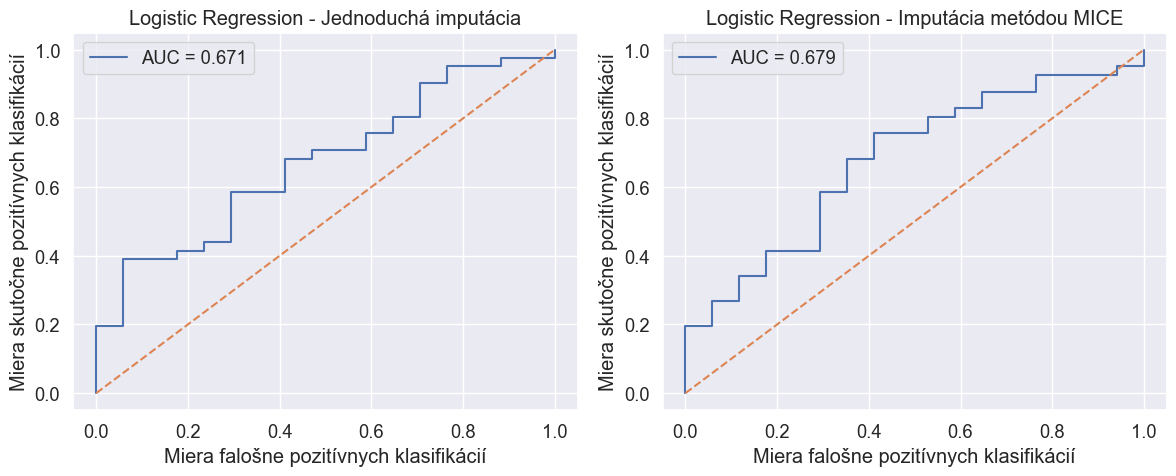

In [22]:
# ROC pre jednoduchú imputáciu
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# ROC pre MICE imputáciu
fpr_lr_mice, tpr_lr_mice, _ = roc_curve(y_test, y_proba_lr_mice)
auc_lr_mice = roc_auc_score(y_test, y_proba_lr_mice)

plt.figure(figsize=(12, 5))

# Simple imputácia 
plt.subplot(1, 2, 1)
plt.plot(fpr_lr, tpr_lr, label=f"AUC = {auc_lr:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Logistic Regression - Jednoduchá imputácia")
plt.xlabel("Miera falošne pozitívnych klasifikácií")
plt.ylabel("Miera skutočne pozitívnych klasifikácií")
plt.legend()

# MICE imputácia 
plt.subplot(1, 2, 2)
plt.plot(fpr_lr_mice, tpr_lr_mice, label=f"AUC = {auc_lr_mice:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Logistic Regression - Imputácia metódou MICE")
plt.xlabel("Miera falošne pozitívnych klasifikácií")
plt.ylabel("Miera skutočne pozitívnych klasifikácií")
plt.legend()

plt.tight_layout()
plt.show()

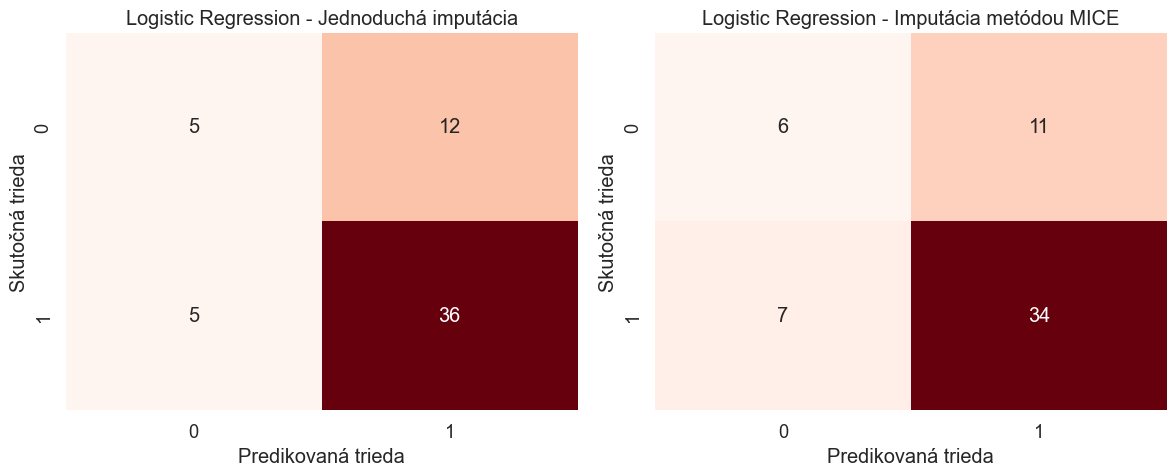

In [23]:
# porovnanie matíc zámen logistickej regresie pri jednoduchej imputácii a MICE imputácii

cm_simple = confusion_matrix(y_test, y_pred_lr)
cm_mice = confusion_matrix(y_test, y_pred_lr_mice)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Simple ---
sns.heatmap(cm_simple, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[0])
axes[0].set_title("Logistic Regression - Jednoduchá imputácia")
axes[0].set_xlabel("Predikovaná trieda")
axes[0].set_ylabel("Skutočná trieda")

# --- MICE ---
sns.heatmap(cm_mice, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[1])
axes[1].set_title("Logistic Regression - Imputácia metódou MICE")
axes[1].set_xlabel("Predikovaná trieda")
axes[1].set_ylabel("Skutočná trieda")

plt.tight_layout()
plt.show()

## Random Forest s jednoduchou imputáciou

Random Forest je ansámblový model založený na viacerých rozhodovacích stromoch. V tejto časti je trénovaný na dátach doplnených jednoduchou imputáciou.

In [25]:
# vytvorenie modelu random forest
rf = RandomForestClassifier(
     n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_depth=None
)
# trénovanie modelu na trénovacích dátach
rf.fit(X_train_imp, y_train)

# predikcia tried a pravdepodobností na testovacích dátach
y_pred_rf = rf.predict(X_test_imp)
y_proba_rf = rf.predict_proba(X_test_imp)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# výpočet a výpis hodnotiacich metrík
print("Random Forest")
print("ROC AUC:", auc_rf)
print("ACC:", acc_rf)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
ROC AUC: 0.8357245337159254
ACC: 0.8103448275862069
Confusion matrix:
 [[10  7]
 [ 4 37]]
              precision    recall  f1-score   support

           0       0.71      0.59      0.65        17
           1       0.84      0.90      0.87        41

    accuracy                           0.81        58
   macro avg       0.78      0.75      0.76        58
weighted avg       0.80      0.81      0.80        58



## Random Forest s MICE imputáciou

Rovnaký model Random Forest je trénovaný na dátach po MICE imputácii, aby bolo možné porovnať vplyv spôsobu doplnenia chýbajúcich hodnôt.

In [27]:
rf_mice = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

rf_mice.fit(X_train_mice_imp, y_train_mice)

y_pred_rf_mice = rf_mice.predict(X_test_mice_imp)
y_proba_rf_mice = rf_mice.predict_proba(X_test_mice_imp)[:, 1]

acc_rf_mice = accuracy_score(y_test_mice, y_pred_rf_mice)
auc_rf_mice = roc_auc_score(y_test_mice, y_proba_rf_mice)

print("Random Forest + MICE")
print("ROC AUC:", auc_rf_mice)
print("ACC:", acc_rf_mice)
print("Confusion matrix:\n", confusion_matrix(y_test_mice, y_pred_rf_mice))
print(classification_report(y_test_mice, y_pred_rf_mice))

Random Forest + MICE
ROC AUC: 0.8823529411764706
ACC: 0.8448275862068966
Confusion matrix:
 [[11  6]
 [ 3 38]]
              precision    recall  f1-score   support

           0       0.79      0.65      0.71        17
           1       0.86      0.93      0.89        41

    accuracy                           0.84        58
   macro avg       0.82      0.79      0.80        58
weighted avg       0.84      0.84      0.84        58



### Porovnanie výsledkov Random Forest

Porovnávajú sa ROC krivky a matice zámen pre Random Forest pri jednoduchej imputácii a pri MICE imputácii.

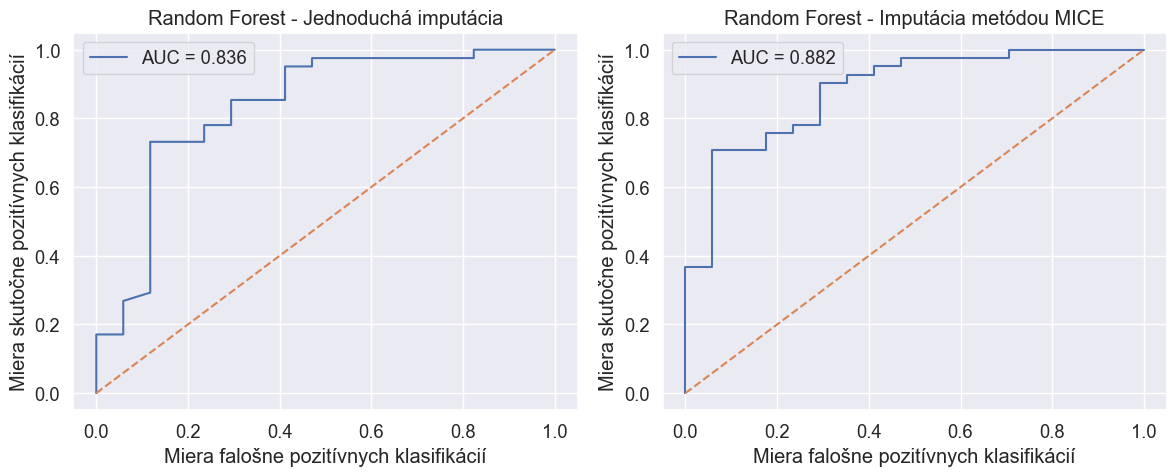

In [29]:
# porovnanie ROC kriviek modelu Random Forest pre dve verzie imputácie
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_rf_mice, tpr_rf_mice, _ = roc_curve(y_test_mice, y_proba_rf_mice)

auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_rf_mice = roc_auc_score(y_test_mice, y_proba_rf_mice)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Simple imputácia
axes[0].plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("Random Forest - Jednoduchá imputácia")
axes[0].set_xlabel("Miera falošne pozitívnych klasifikácií")
axes[0].set_ylabel("Miera skutočne pozitívnych klasifikácií")
axes[0].legend()
# MICE imputácia
axes[1].plot(fpr_rf_mice, tpr_rf_mice, label=f"AUC = {auc_rf_mice:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("Random Forest - Imputácia metódou MICE")
axes[1].set_xlabel("Miera falošne pozitívnych klasifikácií")
axes[1].set_ylabel("Miera skutočne pozitívnych klasifikácií")
axes[1].legend()

plt.tight_layout()
plt.show()

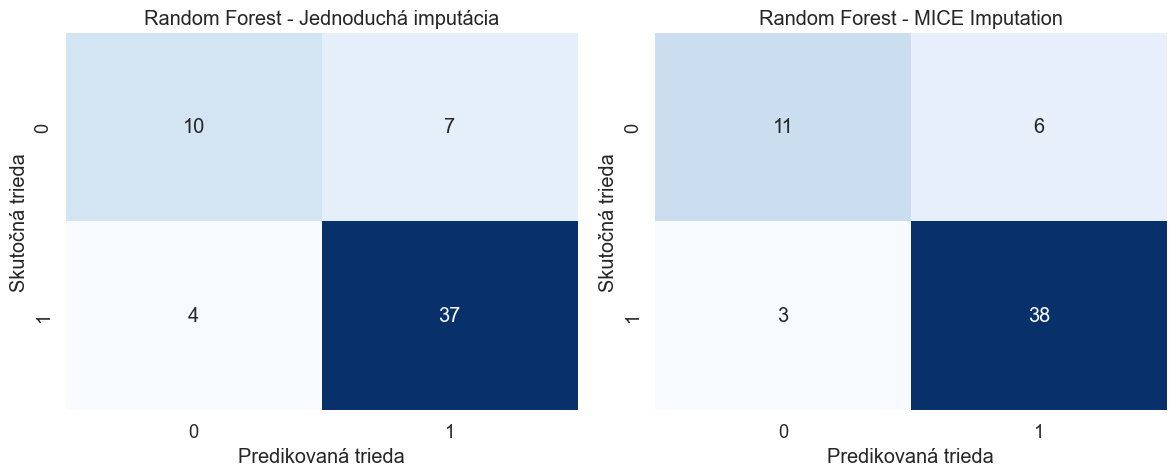

In [30]:
cm_rf_simple = confusion_matrix(y_test, y_pred_rf)
cm_rf_mice = confusion_matrix(y_test, y_pred_rf_mice)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Simple
sns.heatmap(cm_rf_simple, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title("Random Forest - Jednoduchá imputácia")
axes[0].set_xlabel("Predikovaná trieda")
axes[0].set_ylabel("Skutočná trieda")

# MICE 
sns.heatmap(cm_rf_mice, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title("Random Forest - MICE Imputation")
axes[1].set_xlabel("Predikovaná trieda")
axes[1].set_ylabel("Skutočná trieda")

plt.tight_layout()
plt.show()

## Gradient Boosting s jednoduchou imputáciou

Gradient Boosting postupne vytvára viacero rozhodovacích stromov, pričom každý ďalší strom sa snaží opraviť chyby predchádzajúcich. Najskôr je použitá verzia dát s jednoduchou imputáciou.

In [32]:
# vytvorenie modelu Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
# trénovanie modelu na trénovacích dátach
gb.fit(X_train_imp, y_train)

# predikcia tried a pravdepodobností na testovacích dátach
y_pred_gb = gb.predict(X_test_imp)
y_proba_gb = gb.predict_proba(X_test_imp)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_proba_gb)

# výpočet a výpis hodnotiacich metrík
print("Gradient Boosting")
print("ROC AUC:", auc_gb)
print("ACC:", acc_gb)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
ROC AUC: 0.8464849354375896
ACC: 0.7586206896551724
Confusion matrix:
 [[ 8  9]
 [ 5 36]]
              precision    recall  f1-score   support

           0       0.62      0.47      0.53        17
           1       0.80      0.88      0.84        41

    accuracy                           0.76        58
   macro avg       0.71      0.67      0.69        58
weighted avg       0.75      0.76      0.75        58



## Gradient Boosting s MICE imputáciou

Táto časť opakuje trénovanie modelu Gradient Boosting na dátach doplnených metódou MICE.

In [34]:
# vytvorenie modelu Gradient Boosting
gb_mice = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# trénovanie modelu na trénovacích dátach
gb_mice.fit(X_train_mice_imp, y_train_mice)

# predikcia tried a pravdepodobností na testovacích dátach
y_pred_gb_mice = gb_mice.predict(X_test_mice_imp)
y_proba_gb_mice = gb_mice.predict_proba(X_test_mice_imp)[:, 1]

acc_gb_mice = accuracy_score(y_test_mice, y_pred_gb_mice)
auc_gb_mice = roc_auc_score(y_test_mice, y_proba_gb_mice)

# výpočet a výpis hodnotiacich metrík
print("Gradient Boosting + MICE")
print("ROC AUC:", auc_gb_mice)
print("ACC:", acc_gb_mice)
print("Confusion matrix:\n", confusion_matrix(y_test_mice, y_pred_gb_mice))
print(classification_report(y_test_mice, y_pred_gb_mice))


Gradient Boosting + MICE
ROC AUC: 0.8723098995695839
ACC: 0.8275862068965517
Confusion matrix:
 [[10  7]
 [ 3 38]]
              precision    recall  f1-score   support

           0       0.77      0.59      0.67        17
           1       0.84      0.93      0.88        41

    accuracy                           0.83        58
   macro avg       0.81      0.76      0.78        58
weighted avg       0.82      0.83      0.82        58



### Porovnanie výsledkov Gradient Boosting

Porovnávajú sa ROC krivky a matice zámen modelu Gradient Boosting pri oboch spôsoboch imputácie.

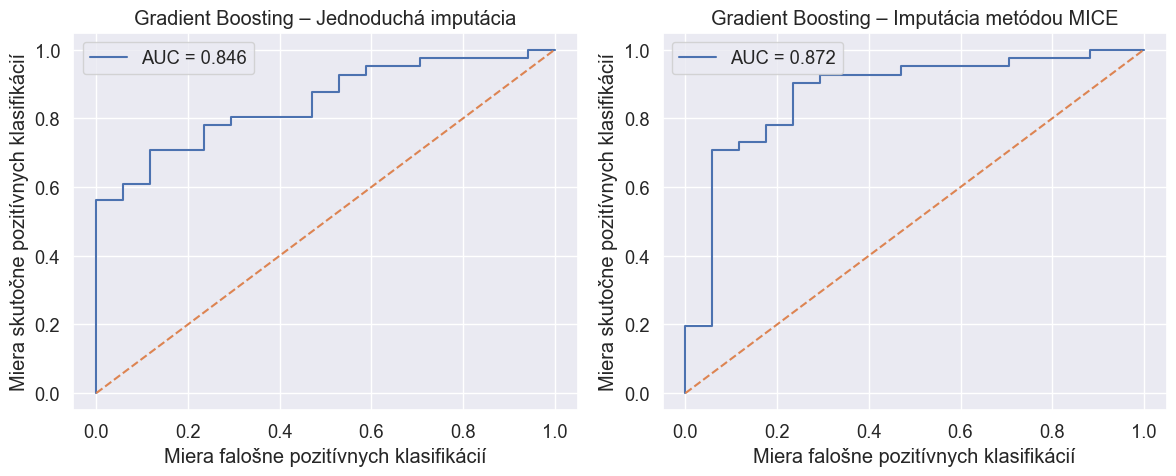

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Simple 
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

axes[0].plot(fpr_gb, tpr_gb, label=f"AUC = {roc_auc_gb:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("Gradient Boosting – Jednoduchá imputácia")
axes[0].set_xlabel("Miera falošne pozitívnych klasifikácií")
axes[0].set_ylabel("Miera skutočne pozitívnych klasifikácií")
axes[0].legend()

# MICE 
fpr_gb_mice, tpr_gb_mice, _ = roc_curve(y_test_mice, y_proba_gb_mice)
roc_auc_gb_mice = roc_auc_score(y_test_mice, y_proba_gb_mice)

axes[1].plot(fpr_gb_mice, tpr_gb_mice, label=f"AUC = {roc_auc_gb_mice:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("Gradient Boosting – Imputácia metódou MICE")
axes[1].set_xlabel("Miera falošne pozitívnych klasifikácií")
axes[1].set_ylabel("Miera skutočne pozitívnych klasifikácií")
axes[1].legend()

plt.tight_layout()
plt.show()

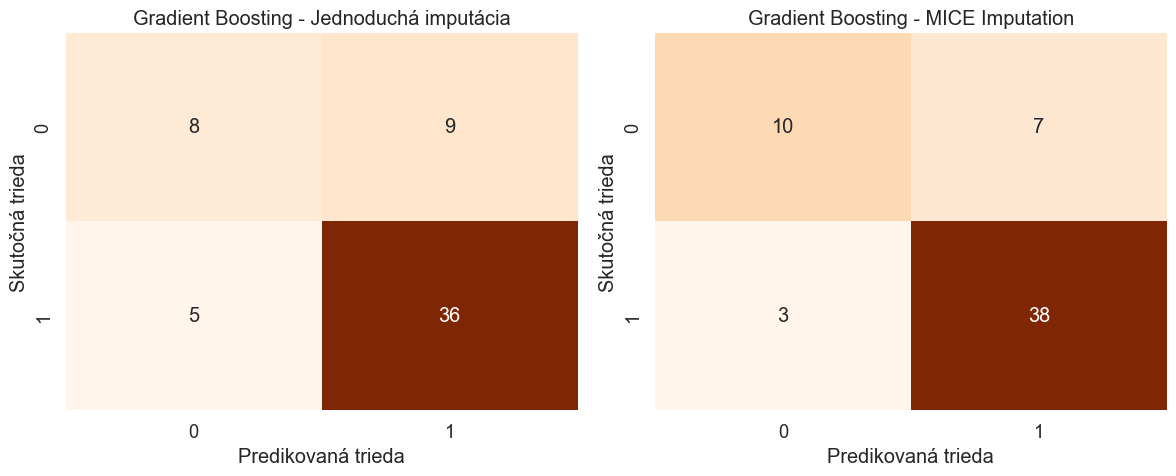

In [37]:
cm_gb_simple = confusion_matrix(y_test, y_pred_gb)
cm_gb_mice = confusion_matrix(y_test_mice, y_pred_gb_mice)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Simple 
sns.heatmap(cm_gb_simple, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[0])
axes[0].set_title("Gradient Boosting - Jednoduchá imputácia")
axes[0].set_xlabel("Predikovaná trieda")
axes[0].set_ylabel("Skutočná trieda")

#  MICE 
sns.heatmap(cm_gb_mice, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1])
axes[1].set_title("Gradient Boosting - MICE Imputation")
axes[1].set_xlabel("Predikovaná trieda")
axes[1].set_ylabel("Skutočná trieda")

plt.tight_layout()
plt.show()

## Porovnanie všetkých modelov pred aplikáciou MICE

Táto časť zobrazuje spoločné matice zámen modelov pri jednoduchej imputácii alebo pri modeli XGBoost bez dodatočnej imputácie.

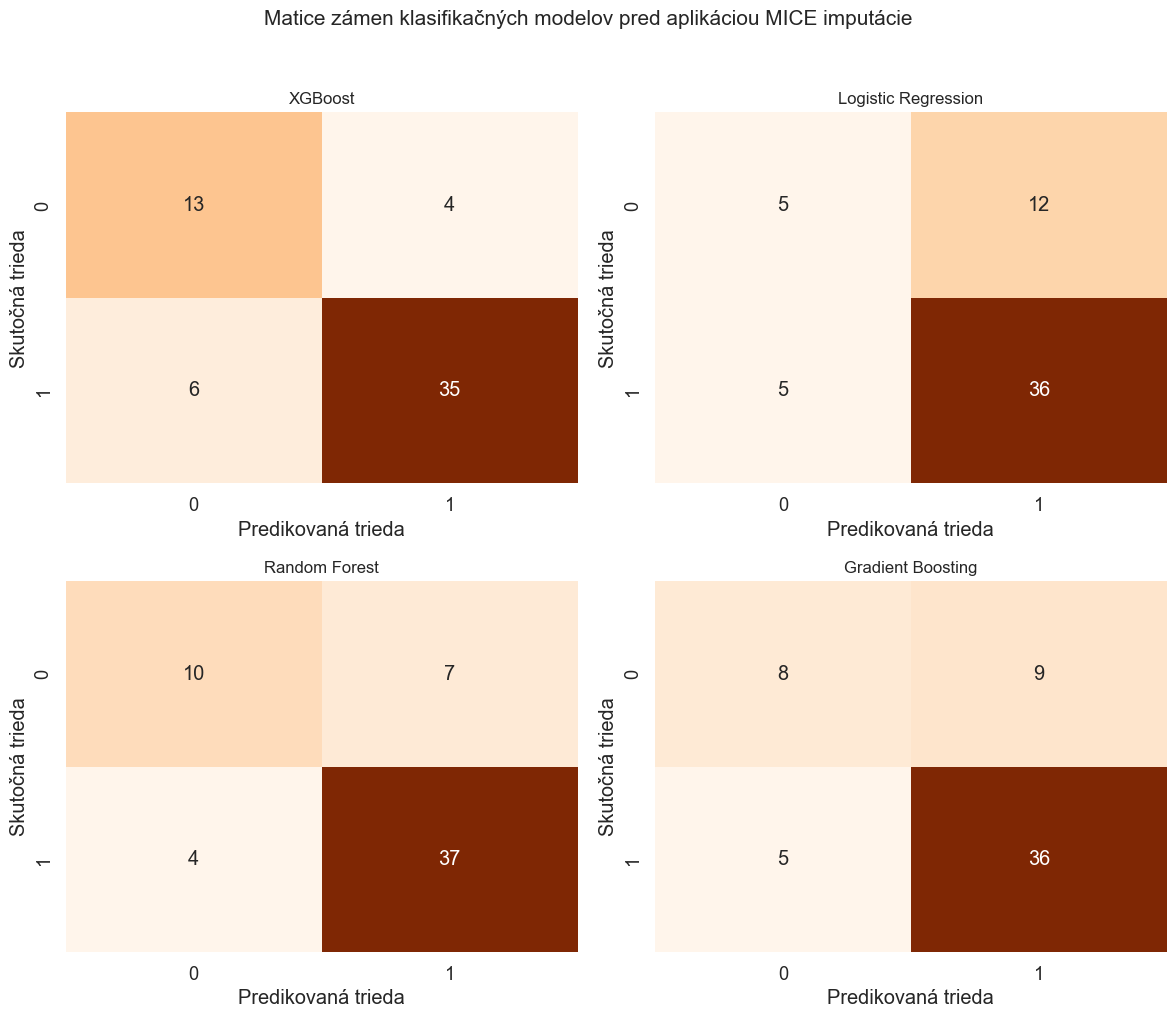

In [39]:
# spoločné zobrazenie matíc zámen modelov pred aplikáciou MICE imputácie
models_before = [
    ("XGBoost", y_test_xgb, y_pred_xgb),
    ("Logistic Regression", y_test, y_pred_lr),
    ("Random Forest", y_test, y_pred_rf),
    ("Gradient Boosting", y_test, y_pred_gb),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, y_true, y_pred) in zip(axes, models_before):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        cbar=False,
        ax=ax
    )

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Predikovaná trieda")
    ax.set_ylabel("Skutočná trieda")

plt.suptitle("Matice zámen klasifikačných modelov pred aplikáciou MICE imputácie", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Porovnanie všetkých modelov po aplikácii MICE

Táto časť porovnáva matice zámen modelov po aplikácii MICE imputácie. XGBoost je ponechaný ako samostatný model, keďže vie pracovať s chýbajúcimi hodnotami priamo.

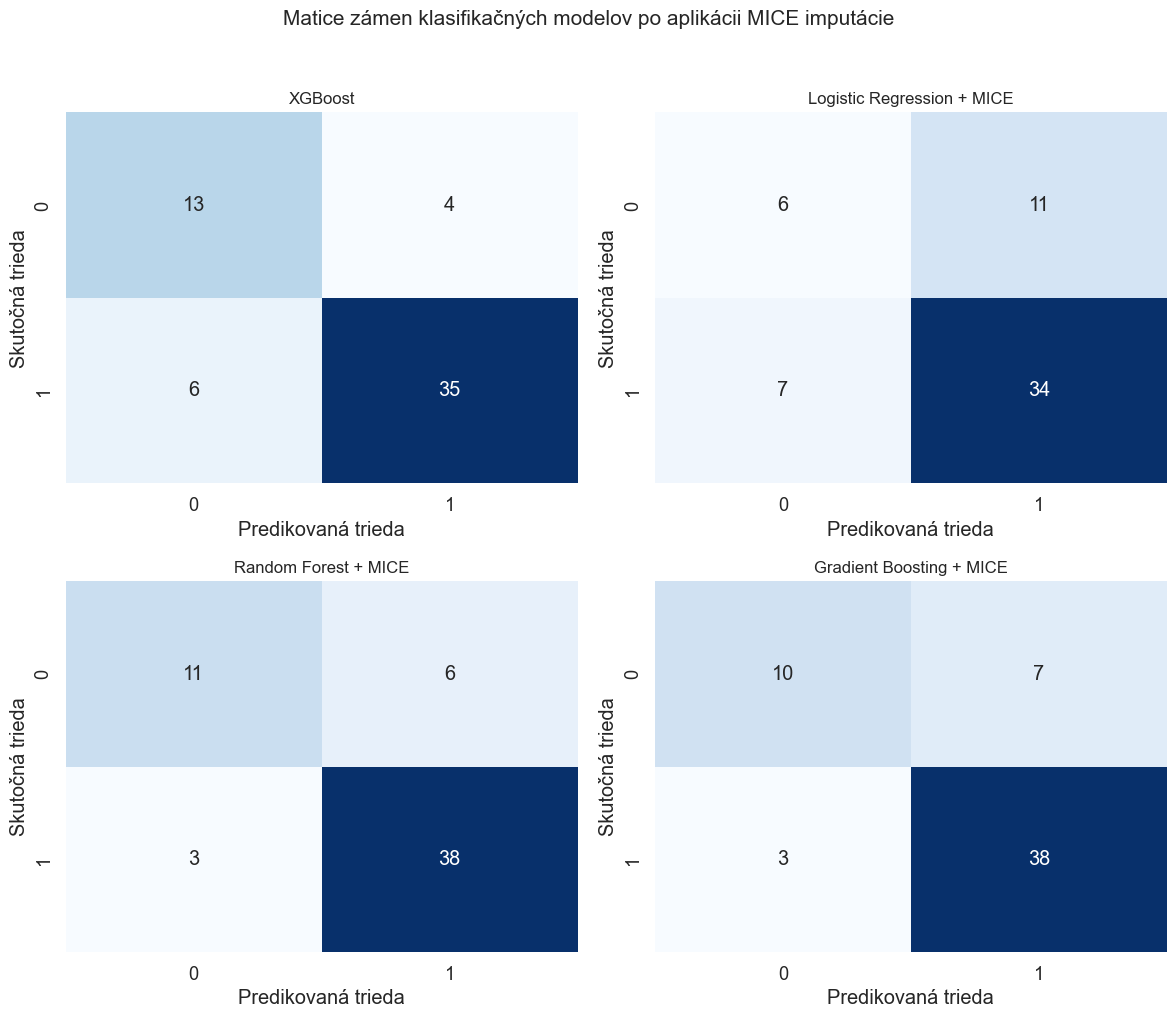

In [41]:
# spoločné zobrazenie matíc zámen modelov po aplikácii MICE imputácie
models_mice = [
    ("XGBoost", y_test_xgb, y_pred_xgb),
    ("Logistic Regression + MICE", y_test_mice, y_pred_lr_mice),
    ("Random Forest + MICE", y_test_mice, y_pred_rf_mice),
    ("Gradient Boosting + MICE", y_test_mice, y_pred_gb_mice),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, y_true, y_pred) in zip(axes, models_mice):

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Predikovaná trieda")
    ax.set_ylabel("Skutočná trieda")

plt.suptitle("Matice zámen klasifikačných modelov po aplikácii MICE imputácie", fontsize=15, y=1.02)

plt.tight_layout()
plt.show()

## Kontrolný experiment: Random Forest bez premenných HUT testu

V tomto experimente sa overuje, či model Random Forest dokáže dosiahnuť dobré výsledky aj bez premenných súvisiacich s HUT testom. Použité sú rovnaké trénovacie a testovacie dáta ako pri modeli Random Forest s MICE imputáciou.

In [43]:
# HUT premenné, ktoré chceme odstrániť
hut_cols = ["SBP_before", "DBP_before", "SBP_tilt", "DBP_tilt"]

# Odstránenie HUT premenných iba z už imputovaných dát
# Pôvodné X_train_mice_imp a X_test_mice_imp zostávajú nezmenené
X_train_mice_no_hut = X_train_mice_imp.drop(
    columns=[col for col in hut_cols if col in X_train_mice_imp.columns]
)

X_test_mice_no_hut = X_test_mice_imp.drop(
    columns=[col for col in hut_cols if col in X_test_mice_imp.columns]
)

print("Počet premenných s HUT:", X_train_mice_imp.shape[1])
print("Počet premenných bez HUT:", X_train_mice_no_hut.shape[1])
print("Odstránené HUT premenné:", [col for col in hut_cols if col in X_train_mice_imp.columns])

# Random Forest + MICE bez HUT premenných
rf_mice_no_hut = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

rf_mice_no_hut.fit(X_train_mice_no_hut, y_train_mice)

y_pred_rf_mice_no_hut = rf_mice_no_hut.predict(X_test_mice_no_hut)
y_proba_rf_mice_no_hut = rf_mice_no_hut.predict_proba(X_test_mice_no_hut)[:, 1]

acc_rf_mice_no_hut = accuracy_score(y_test_mice, y_pred_rf_mice_no_hut)
auc_rf_mice_no_hut = roc_auc_score(y_test_mice, y_proba_rf_mice_no_hut)

print("Random Forest + MICE bez HUT premenných")
print("ROC AUC:", auc_rf_mice_no_hut)
print("ACC:", acc_rf_mice_no_hut)
print("Confusion matrix:\n", confusion_matrix(y_test_mice, y_pred_rf_mice_no_hut))
print(classification_report(y_test_mice, y_pred_rf_mice_no_hut))

Počet premenných s HUT: 19
Počet premenných bez HUT: 15
Odstránené HUT premenné: ['SBP_before', 'DBP_before', 'SBP_tilt', 'DBP_tilt']
Random Forest + MICE bez HUT premenných
ROC AUC: 0.9160688665710186
ACC: 0.8620689655172413
Confusion matrix:
 [[13  4]
 [ 4 37]]
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        17
           1       0.90      0.90      0.90        41

    accuracy                           0.86        58
   macro avg       0.83      0.83      0.83        58
weighted avg       0.86      0.86      0.86        58



In [44]:
# vytvorenie porovnávacej tabuľky výsledkov modelu Random Forest s HUT premennými a bez nich
comparison_rf_hut = pd.DataFrame({
    "Variant modelu": [
        "Random Forest + MICE s HUT premennými",
        "Random Forest + MICE bez HUT premenných"
    ],
    "Accuracy": [
        acc_rf_mice,
        acc_rf_mice_no_hut
    ],
    "AUC": [
        auc_rf_mice,
        auc_rf_mice_no_hut
    ]
})

comparison_rf_hut

,Variant modelu,Accuracy,AUC
0,Random Forest + MICE s HUT premennými,0.844828,0.882353
1,Random Forest + MICE bez HUT premenných,0.862069,0.916069


# Analýza rizikových faktorov

Nasledujúca časť vyhodnocuje dôležitosť vstupných premenných pre jednotlivé modely. Cieľom je identifikovať faktory, ktoré sa opakovane objavujú medzi najdôležitejšími premennými.

In [46]:
# PREMENOVANIE OZNAK NA ZROZUMITEĽNÉ NÁZVY

features = X_train_imp.columns.tolist()

feature_labels = {
    "Pohlavie":   "Pohlavie",
    "Vek":        "Vek",
    "O1":         "Náhle úmrtie člena rodiny(O1)",
    "P1":         "Ochorenie srdca 1 (P1)",
    "P2":         "Ochorenie srdca 2 (P2)",
    "P3":         "Ochorenie chlopní (P3)",
    "P4":         "Srdcová slabosť (P4)",
    "P5":         "Koronárna chorova srdca (P5)",
    "P6":         "Srdcové arytmie (P6)",
    "P10":        "Vysoký tlak krvi (P10)",
    "P11":        "Nízky tlak krvi (P11)",
    "P14":        "Cukrovka (P14)",
    "P15":        "Anémia (P15)",
    "P24":        "Neurologické ochorenia (P24)",
    "P26":        "Psychiatrické ochorenia (P26)",
    "SBP_before": "Systolický tlak pred HUT testom",
    "DBP_before": "Diastolický tlak pred HUT testom",
    "SBP_tilt":   "Systolický tlak počas HUT testu",
    "DBP_tilt":   "Diastolický tlak počas HUT testu",
}

# tabuľka na kontrolu
feature_names_table = pd.DataFrame({
    "Pôvodný názov": features,
    "Popis": [feature_labels.get(f, f) for f in features]
})

print("\nTabuľka názvov premenných:")
print(feature_names_table.to_string(index=False))


Tabuľka názvov premenných:
Pôvodný názov                            Popis
     Pohlavie                         Pohlavie
          Vek                              Vek
           O1    Náhle úmrtie člena rodiny(O1)
           P1           Ochorenie srdca 1 (P1)
           P2           Ochorenie srdca 2 (P2)
           P3           Ochorenie chlopní (P3)
           P4             Srdcová slabosť (P4)
           P5     Koronárna chorova srdca (P5)
           P6             Srdcové arytmie (P6)
          P10           Vysoký tlak krvi (P10)
          P11            Nízky tlak krvi (P11)
          P14                   Cukrovka (P14)
          P15                     Anémia (P15)
          P24     Neurologické ochorenia (P24)
          P26    Psychiatrické ochorenia (P26)
   SBP_before  Systolický tlak pred HUT testom
   DBP_before Diastolický tlak pred HUT testom
     SBP_tilt  Systolický tlak počas HUT testu
     DBP_tilt Diastolický tlak počas HUT testu


In [47]:
# vytvorenie slovníka zrozumiteľných názvov premenných pre interpretáciu výsledkov
def plot_top15_factors(feature_names, importances, feature_labels, title, figsize=(14, 8)):
    df_imp = pd.DataFrame({
        "Premenná": feature_names,
        "Dôležitosť": importances
    })

    df_imp["Popis"] = df_imp["Premenná"].map(feature_labels).fillna(df_imp["Premenná"])
    df_imp = df_imp.sort_values("Dôležitosť", ascending=False).head(15).copy()

    # aby najdôležitejší faktor bol hore
    df_imp = df_imp.iloc[::-1]

    plt.figure(figsize=figsize)

    # farebný gradient pre prehľadnejšie zobrazenie dôležitosti premenných
    colors = plt.cm.Blues(np.linspace(0.25, 0.85, len(df_imp)))

    bars = plt.barh(
        df_imp["Popis"],
        df_imp["Dôležitosť"],
        color=colors,
        edgecolor="white",
        height=0.72
    )
    max_val = df_imp["Dôležitosť"].max()
    plt.xlim(0, max_val * 1.15)

    # doplnenie číselných hodnôt na koniec stĺpcov
    for bar, value in zip(bars, df_imp["Dôležitosť"]):
        plt.text(
            bar.get_width() + 0.0015,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}",
            va="center",
            ha="left",
            fontsize=14
        )

    plt.title(title, fontsize=24, pad=20)
    plt.xlabel("Dôležitosť", fontsize=18, labelpad=15)
    plt.ylabel("")
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=16)

    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.gca().set_axisbelow(True)

    # щdstránenie hornej a pravej časti rámčeka grafu
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

## TOP 15 rizikových faktorov – XGBoost ##

In [49]:
xgb_importance = pd.DataFrame({
    "Premenná": X_train_imp.columns,
    "Dôležitosť": xgb.feature_importances_
})

xgb_importance["Popis"] = xgb_importance["Premenná"].map(feature_labels)
xgb_importance = xgb_importance.sort_values(by="Dôležitosť", ascending=False).reset_index(drop=True)
xgb_importance.index = xgb_importance.index + 1

top15_xgb = xgb_importance.head(15)

print("TOP 15 rizikových faktorov – XGBoost")
print(top15_xgb[["Popis", "Dôležitosť"]].to_string())

TOP 15 rizikových faktorov – XGBoost
                               Popis  Dôležitosť
1             Ochorenie chlopní (P3)    0.125749
2                           Pohlavie    0.071589
3   Diastolický tlak pred HUT testom    0.066860
4       Neurologické ochorenia (P24)    0.062750
5             Ochorenie srdca 1 (P1)    0.062673
6               Srdcové arytmie (P6)    0.059723
7             Vysoký tlak krvi (P10)    0.057336
8       Koronárna chorova srdca (P5)    0.053270
9                     Cukrovka (P14)    0.053265
10  Diastolický tlak počas HUT testu    0.049816
11                               Vek    0.049134
12            Ochorenie srdca 2 (P2)    0.047539
13   Systolický tlak počas HUT testu    0.047003
14     Náhle úmrtie člena rodiny(O1)    0.043450
15             Nízky tlak krvi (P11)    0.041727


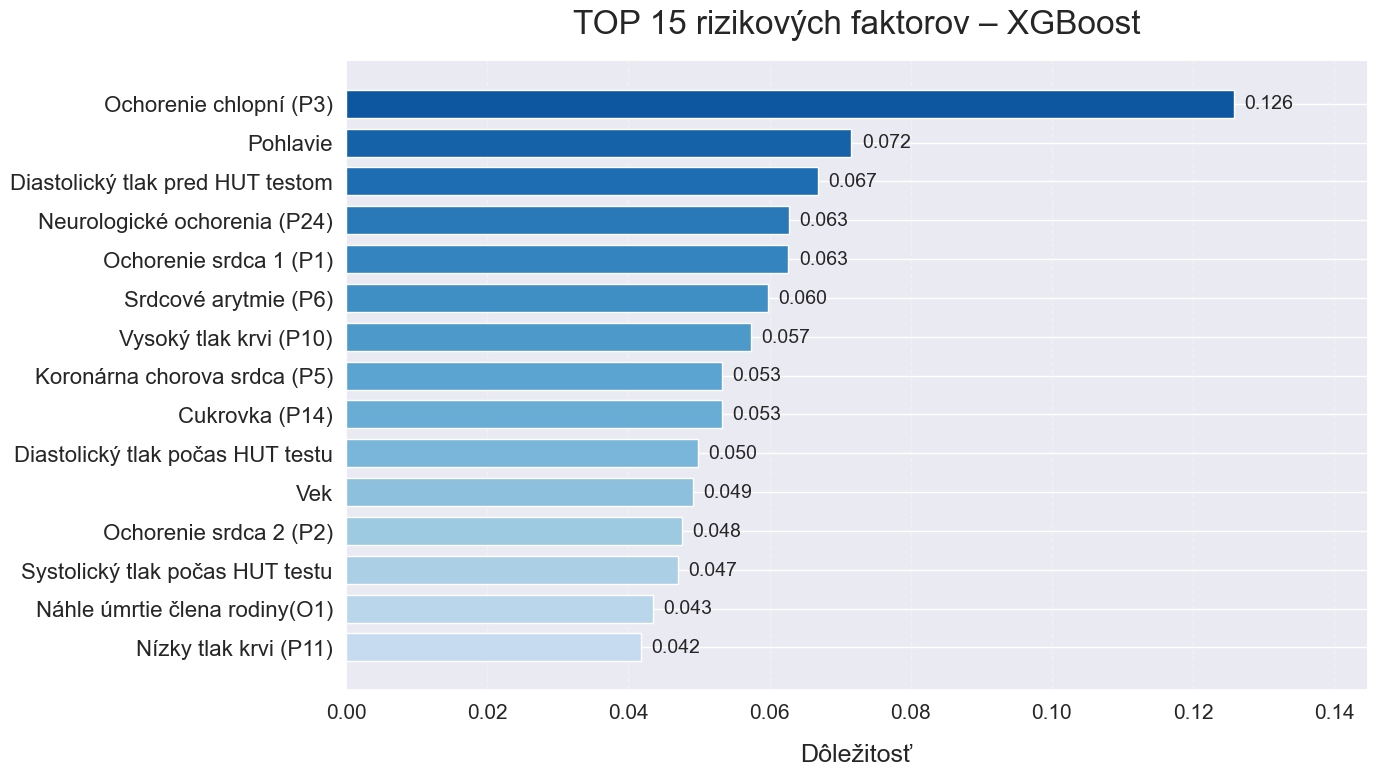

In [50]:
plot_top15_factors(
    feature_names=X_train_imp.columns,
    importances=xgb.feature_importances_,
    feature_labels=feature_labels,
    title="TOP 15 rizikových faktorov – XGBoost"
)

plt.show()

## TOP 15 rizikových faktorov – Random Forest ##

In [52]:
rf_importance = pd.DataFrame({
    "Premenná": X_train_mice_imp.columns,
    "Dôležitosť": rf_mice.feature_importances_
})

rf_importance["Popis"] = rf_importance["Premenná"].map(feature_labels)
rf_importance = rf_importance.sort_values(by="Dôležitosť", ascending=False).reset_index(drop=True)
rf_importance.index = rf_importance.index + 1

top15_rf = rf_importance.head(15)

print("TOP 15 rizikových faktorov – Random Forest + MICE")
print(top15_rf[["Popis", "Dôležitosť"]].to_string())

TOP 15 rizikových faktorov – Random Forest + MICE
                               Popis  Dôležitosť
1                                Vek    0.229844
2    Systolický tlak pred HUT testom    0.134459
3    Systolický tlak počas HUT testu    0.120037
4   Diastolický tlak pred HUT testom    0.102685
5   Diastolický tlak počas HUT testu    0.089587
6                           Pohlavie    0.050483
7       Neurologické ochorenia (P24)    0.042609
8             Ochorenie srdca 1 (P1)    0.041716
9             Vysoký tlak krvi (P10)    0.038725
10     Náhle úmrtie člena rodiny(O1)    0.038643
11              Srdcové arytmie (P6)    0.026994
12            Ochorenie srdca 2 (P2)    0.017138
13             Nízky tlak krvi (P11)    0.016443
14                      Anémia (P15)    0.015521
15     Psychiatrické ochorenia (P26)    0.013738


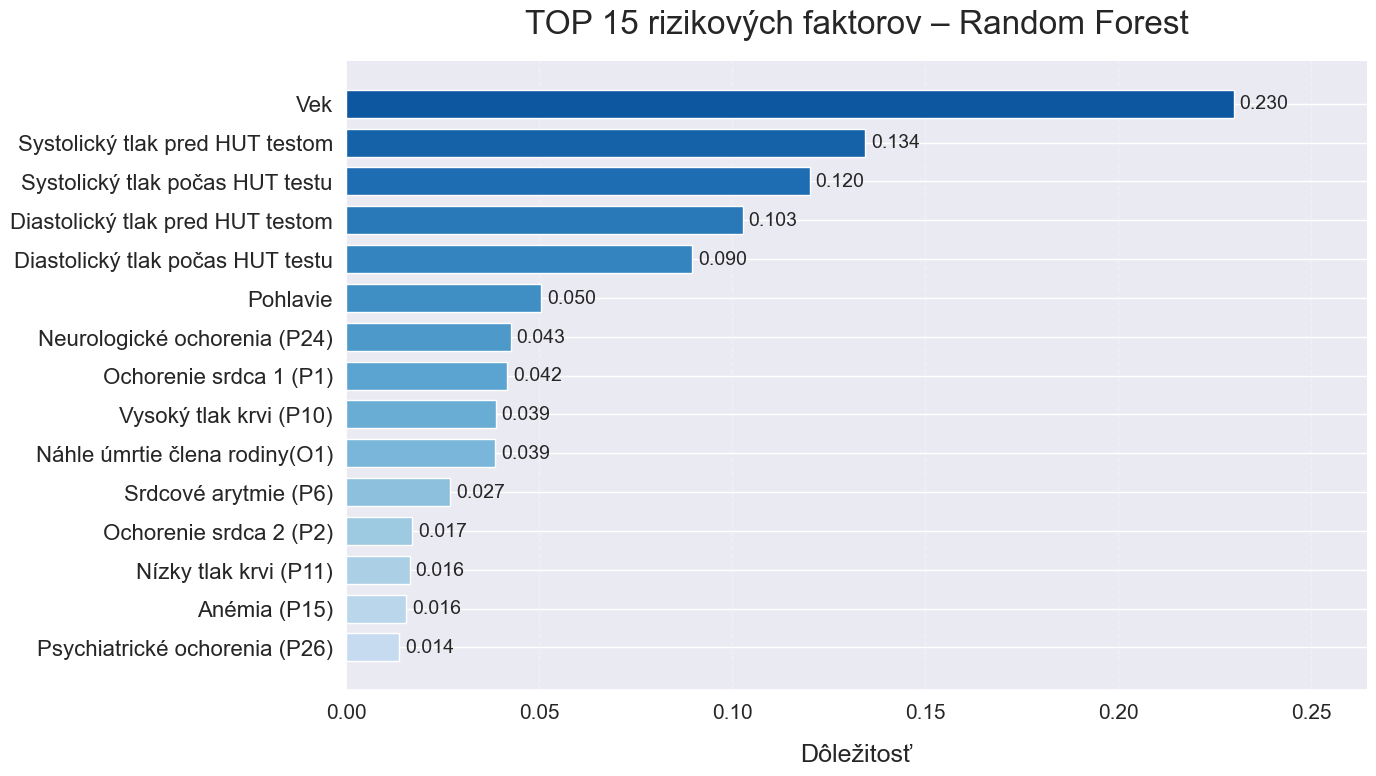

In [53]:
plot_top15_factors(
    feature_names=X_train_mice_imp.columns,
    importances=rf_mice.feature_importances_,
    feature_labels=feature_labels,
    title="TOP 15 rizikových faktorov – Random Forest"
)
plt.show()

## TOP 15 rizikových faktorov – GradientBoosting ##

In [55]:
gb_importance = pd.DataFrame({
    "Premenná": X_train_mice_imp.columns,
    "Dôležitosť": gb_mice.feature_importances_
})

gb_importance["Popis"] = gb_importance["Premenná"].map(feature_labels)
gb_importance = gb_importance.sort_values(by="Dôležitosť", ascending=False).reset_index(drop=True)
gb_importance.index = gb_importance.index + 1

top15_gb = gb_importance.head(15)

print("TOP 15 rizikových faktorov – Gradient Boosting + MICE")
print(top15_gb[["Popis", "Dôležitosť"]].to_string())

TOP 15 rizikových faktorov – Gradient Boosting + MICE
                               Popis  Dôležitosť
1                                Vek    0.344491
2   Diastolický tlak pred HUT testom    0.144948
3    Systolický tlak pred HUT testom    0.115252
4    Systolický tlak počas HUT testu    0.089029
5                           Pohlavie    0.058907
6   Diastolický tlak počas HUT testu    0.048927
7             Ochorenie srdca 1 (P1)    0.033226
8             Vysoký tlak krvi (P10)    0.029195
9               Srdcové arytmie (P6)    0.027955
10      Neurologické ochorenia (P24)    0.025268
11      Koronárna chorova srdca (P5)    0.023900
12     Náhle úmrtie člena rodiny(O1)    0.023465
13            Ochorenie srdca 2 (P2)    0.012530
14             Nízky tlak krvi (P11)    0.009702
15                    Cukrovka (P14)    0.005174


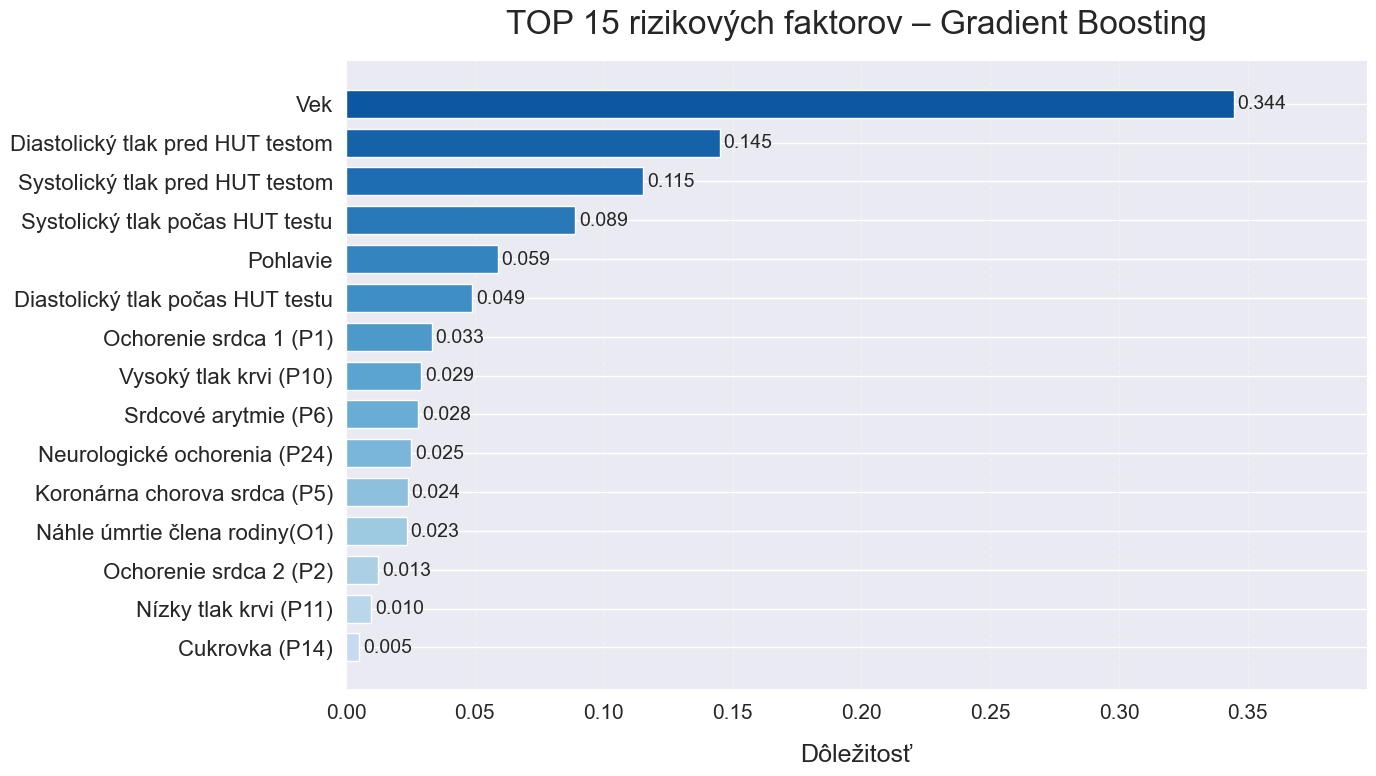

In [56]:
plot_top15_factors(
    feature_names=X_train_mice_imp.columns,
    importances=gb_mice.feature_importances_,
    feature_labels=feature_labels,
    title="TOP 15 rizikových faktorov – Gradient Boosting"
)
plt.show()

## TOP 15 rizikových faktorov – Logistic Regression ##

In [58]:
lr_importance = pd.DataFrame({
    "Premenná": X_train_mice_imp.columns,
    "Dôležitosť": lr_mice.coef_[0]
})

lr_importance["Popis"] = lr_importance["Premenná"].map(feature_labels)
lr_importance = lr_importance.sort_values(by="Dôležitosť", ascending=False).reset_index(drop=True)
lr_importance.index = lr_importance.index + 1

top15_lr = lr_importance.head(15)

print("TOP 15 rizikových faktorov – Logistic Regression + MICE")
print(top15_lr[["Popis", "Dôležitosť"]].to_string())

TOP 15 rizikových faktorov – Logistic Regression + MICE
                               Popis  Dôležitosť
1               Srdcové arytmie (P6)    0.679228
2       Neurologické ochorenia (P24)    0.449261
3             Ochorenie chlopní (P3)    0.442101
4    Systolický tlak počas HUT testu    0.313399
5             Ochorenie srdca 1 (P1)    0.302735
6              Nízky tlak krvi (P11)    0.196677
7   Diastolický tlak pred HUT testom    0.190529
8                                Vek    0.077153
9      Náhle úmrtie člena rodiny(O1)    0.039582
10                      Anémia (P15)    0.024313
11     Psychiatrické ochorenia (P26)    0.000871
12              Srdcová slabosť (P4)    0.000000
13                    Cukrovka (P14)   -0.060931
14      Koronárna chorova srdca (P5)   -0.179326
15            Vysoký tlak krvi (P10)   -0.226770


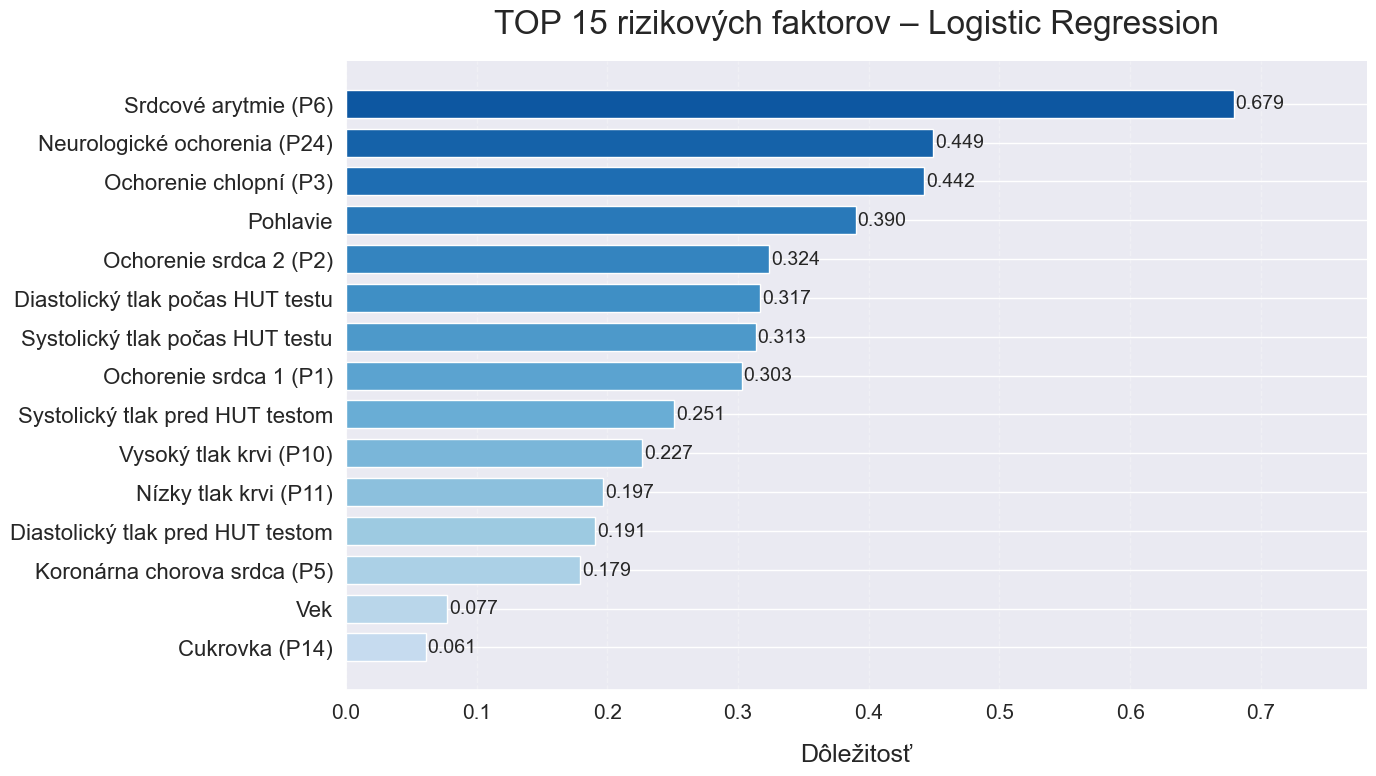

In [59]:
plot_top15_factors(
    feature_names=X_train_mice_imp.columns,
    importances=np.abs(lr_mice.coef_[0]),
    feature_labels=feature_labels,
    title="TOP 15 rizikových faktorov – Logistic Regression"
)

plt.show()

## Porovnanie poradia TOP 15 rizikových faktorov pre jednotlivé klasifikačné modely

Na záver sa vytvára spoločná tabuľka poradia najdôležitejších premenných. Táto tabuľka slúži na identifikáciu rizikových faktorov, ktoré sa opakujú vo viacerých modeloch.

In [61]:
TOP_N = 15

# --- XGBoost ---
xgb_rank = pd.Series(
    X_train_imp.columns[np.argsort(xgb.feature_importances_)[::-1][:TOP_N]],
    name="XGBoost"
)

# --- Random Forest ---
rf_rank = pd.Series(
    X_train_mice_imp.columns[np.argsort(rf_mice.feature_importances_)[::-1][:TOP_N]],
    name="Random Forest"
)

# --- Gradient Boosting ---
gb_rank = pd.Series(
    X_train_mice_imp.columns[np.argsort(gb_mice.feature_importances_)[::-1][:TOP_N]],
    name="Gradient Boosting"
)

# --- Logistic Regression ---
lr_coefs = lr_mice.coef_[0]
lr_rank = pd.Series(
    X_train_mice_imp.columns[np.argsort(np.abs(lr_coefs))[::-1][:TOP_N]],
    name="Logistic Regression"
)

# --- Spojenie poradí dôležitosti premenných zo všetkých modelov do jednej tabuľky ---
rank_table = pd.concat([xgb_rank, rf_rank, gb_rank, lr_rank], axis=1)



# --- Nastavenie indexu tabuľky ako poradia rizikových faktorov ---
rank_table.index = np.arange(1, TOP_N + 1)
rank_table.index.name = "Rank"

print(rank_table.to_string())

         XGBoost Random Forest Gradient Boosting Logistic Regression
Rank                                                                
1             P3           Vek               Vek                  P6
2       Pohlavie    SBP_before        DBP_before                 P24
3     DBP_before      SBP_tilt        SBP_before                  P3
4            P24    DBP_before          SBP_tilt            Pohlavie
5             P1      DBP_tilt          Pohlavie                  P2
6             P6      Pohlavie          DBP_tilt            DBP_tilt
7            P10           P24                P1            SBP_tilt
8             P5            P1               P10                  P1
9            P14           P10                P6          SBP_before
10      DBP_tilt            O1               P24                 P10
11           Vek            P6                P5                 P11
12            P2            P2                O1          DBP_before
13      SBP_tilt           P11    